In [20]:
import cga_utils
import prompt_versions
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
from langchain.globals import set_llm_cache
from langchain_community.cache import SQLiteCache

set_llm_cache(SQLiteCache(database_path=".langchain.ollama38.db"))

In [22]:
from langchain_community.chat_models import ChatOllama
llm = ChatOllama(model="qwen3:4b")  # vagy bármely más elérhető Ollama modell

In [31]:
import pandas as pd
messages = prompt_versions.prompt_versions['V22']
messages = [(a, t.replace('/no_think','')) for (a,t)  in messages]
messages[-1] = ( messages[-1][0],  messages[-1][1] + "/no_think" ) 

#problematic_qids = list(pd.read_csv('res/e38_22.csv').query('error_code == "selection_error" and calc_pattern == "#-#"')['qid'])
#df = pd.read_csv('res/e38_22.csv')
#problematic_qids = list(df[df["question"].str.contains("percentage change")]['qid'])

#res = cga_utils.execute_datset_predictions(llm, messages, problematic_qids)
res = cga_utils.execute_datset_predictions(llm, messages)


#problematic_qids = list(pd.read_csv('res/e37.csv').query('error_code == "selection_error" and calc_pattern == "(#+#)/#"')['qid'])
#df = pd.read_csv('res/e38_19.csv')
#problematic_qids = list(df[df["question"].str.contains("percentage change")]['qid'])

#res = cga_utils.execute_datset_predictions(llm, messages, problematic_qids)
#res = cga_utils.execute_datset_predictions(llm, messages)

0it [00:00, ?it/s]

b2786c1a-37de-4120-b03c-32bf5c81f157
What was the change in the amount for Appliances in 2019 from 2018? Success: -94.0
<< 680-774 || [680.0, 774.0, -94.0] || [680.0, 774.0] || True >>
fe11f001-3bfe-4089-8108-412676f0a780
What was the percentage change in the amount for Appliances in 2019 from 2018? Success: -12.14
<< (680-774)/774 || [680.0, 774.0, -12.144702842377262] || [680.0, 774.0, 774.0] || True >>
5103aed0-b4e8-4fae-bf78-e2c9f4ba84cf
What is the difference between the domestic and international discount rates as at September 30, 2019? Success: 2.1
<< 4.00 - 1.90  || [4.0, 1.9] || [4.0, 1.9] || True >>
4dc8be43-d8d9-4b08-9ffd-9c19012361ce
What is the year on year percentage change in domestic discount rate between 2018 and 2019? Success: 6.67
<< (4.00 - 3.75)/3.75  || [3.75, 4.0, 6.666666666666667] || [4.0, 3.75, 3.75] || True >>
6c44a1a8-0785-43a0-90ab-7e21df2c57d9
What is the year on year percentage change in international expected return on plan assets between 2018 and 2019? 

KeyboardInterrupt: 

In [24]:
annotated_results = cga_utils.annotate_results(res)
#annotated_results.to_csv('res/Ollama_2_gemma3n_e4b_code_values_v11_m1.csv')
cga_utils.calc_overall_value_match(annotated_results)

0.25

In [25]:

cga_utils.calc_overall_em(annotated_results), cga_utils.calc_overall_em_alt(annotated_results)

(0.25, 0.25)

In [18]:
annotated_results.to_csv('res/e38_22.csv')

In [30]:
annotated_results

,qid,question,derivation,calc_pattern,pred,pred_scale,answer,scale,value_match,selection_success,...,is_parenth_in_table,has_code_abs,error_text,value_list,code,selected_values,needed_values,exact_match,error_code,aggr_calc_pattern
0,ef274d2b-fbd6-4e9f-95f9-79b37827d91c,What was the total expenses for Oracle in 2018?,"39,383-3,587",#-#,46316.0,million,35796.0,million,False,False,...,False,False,,"[{'number_value': 39506.0, 'scale': 'million',...",def run(value_list):\n for item in value_li...,"[39383.0, 13264.0, 57035.0, 137851.0, 60619.0,...","[39383.0, 3587.0]",False,selection_error,#-#
1,f12806ca-aa4c-4fe6-84fc-10cefca76a9e,What is the change in the operating revenue un...,"154,159-176,931",#-#,-13.22,percent,-22772.0,thousand,False,False,...,True,False,,"[{'number_value': 154159.0, 'scale': 'thousand...",def run(value_list):\n for item in value_li...,"[-13.0, 154585.0, 178139.0, -13.222259022448762]","[154159.0, 176931.0]",False,selection_error,#-#
2,e81574d8-f9e8-48b3-85ab-a7ed36f8cbb0,What was the change in Acquisition and integra...,17-8,#-#,9.0,million,9.0,million,True,True,...,False,False,,"[{'number_value': 17.0, 'scale': 'million', 'c...",def run(value_list):\n acquisition_2019 = N...,"[17.0, 8.0, 9.0]","[17.0, 8.0]",True,none,#-#
3,ff1e12e8-e148-470f-95a8-3f23e02fa62d,What is the net difference in sale of modules ...,"958,115 - 304,397",#-#,653.72,thousand,653718.0,thousand,False,False,...,True,False,,"[{'number_value': 1460116.0, 'scale': 'thousan...",def run(value_list):\n modules_2017 = next(...,"[806398.0, 1460116.0]",[958115.0],False,selection_error,#-#
4,4608c69d-d134-4d16-b639-731f5d3b03cd,What is the change in Cost of revenue of Softw...,"2,322-2,918",#-#,-596.0,thousand,-596.0,thousand,True,True,...,True,False,,"[{'number_value': 9441.0, 'scale': 'thousand',...",def run(value_list):\n # Filter for Cost of...,"[2322.0, 2918.0, -596.0]","[2322.0, 2918.0]",True,none,#-#
5,0550ae54-99f4-4b87-b1a7-11d402a94918,What is the change in Cost of revenue of Clien...,830-261,#-#,569.0,thousand,569.0,thousand,True,True,...,True,False,,"[{'number_value': 9441.0, 'scale': 'thousand',...",def run(value_list):\n # Filter for Cost of...,"[830.0, 261.0, 569.0]","[830.0, 261.0]",True,none,#-#
6,34144864-790c-4733-8323-91347f68f5ef,What is the global increase / (decrease) in th...,7 - 10,#-#,-66.67,percent,-3.0,,False,False,...,False,False,,"[{'number_value': 7.0, 'scale': '', 'category'...",def run(value_list):\n hindi_2018 = None\n ...,"[3.0, 1.0, -66.66666666666666]","[7.0, 10.0]",False,selection_error,#-#
7,e9b75381-50b1-4717-a322-31ed1eef4259,What is the global increase / (decrease) in th...,1 - 3,#-#,2.0,,-2.0,,False,True,...,False,False,,"[{'number_value': 7.0, 'scale': '', 'category'...",def run(value_list):\n tamil_2017 = next(v[...,"[3.0, 1.0, -2.0]","[1.0, 3.0]",False,sign_error,#-#
8,190316bd-8f09-4e44-9648-e83d0bab44fb,What was the change in Impairment losses betwe...,"200,657-50,565",#-#,0.0,,150092.0,thousand,False,False,...,True,False,,"[{'number_value': -265511.0, 'scale': 'thousan...",def run(value_list):\n # Filter impairment ...,"[200657.0, 200657.0, 0.0]","[200657.0, 50565.0]",False,selection_error,#-#
9,fd8d07ff-964d-4689-a845-575b95201ca5,What is the increase / (decrease) in the Weigh...,44.8 - 44.3,#-#,0.0,million,0.5,million,False,False,...,True,False,,"[{'number_value': -31.5, 'scale': '', 'categor...",def run(value_list):\n # Filter values for ...,"[44.8, 44.8, 0.0]","[44.8, 44.3]",False,selection_error,#-#


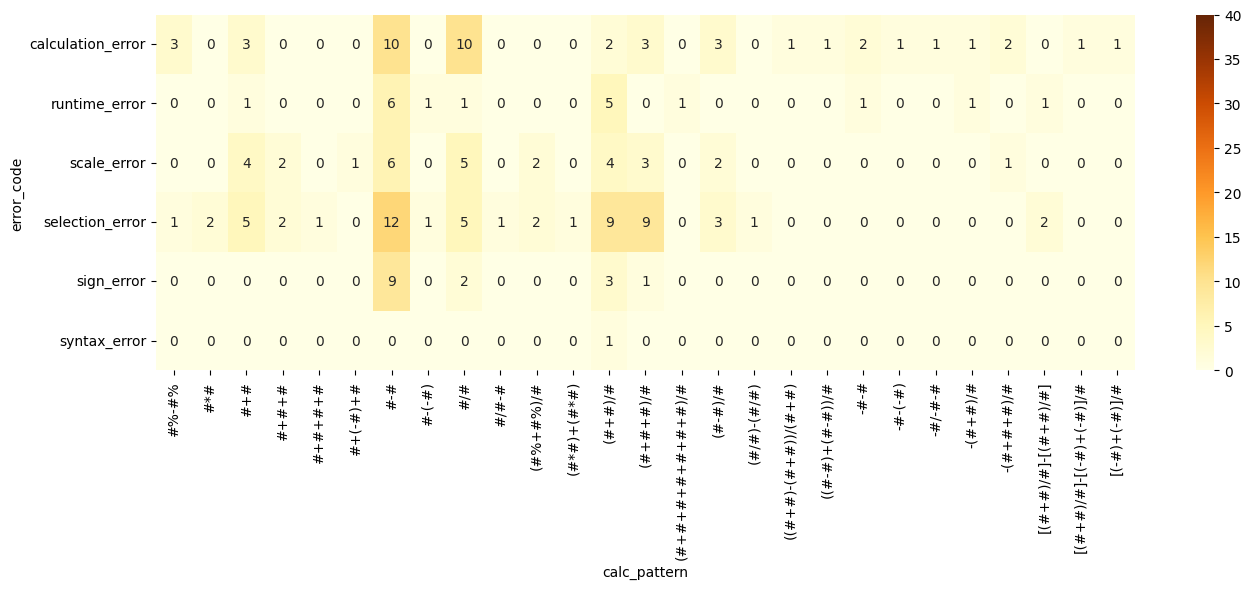

166

In [19]:
df = annotated_results.query('error_code != "none"')
cga_utils.crosstab_heatmap(df, 'error_code', 'calc_pattern', 40)
len(df)

Series([], Name: exact_match, dtype: float64)


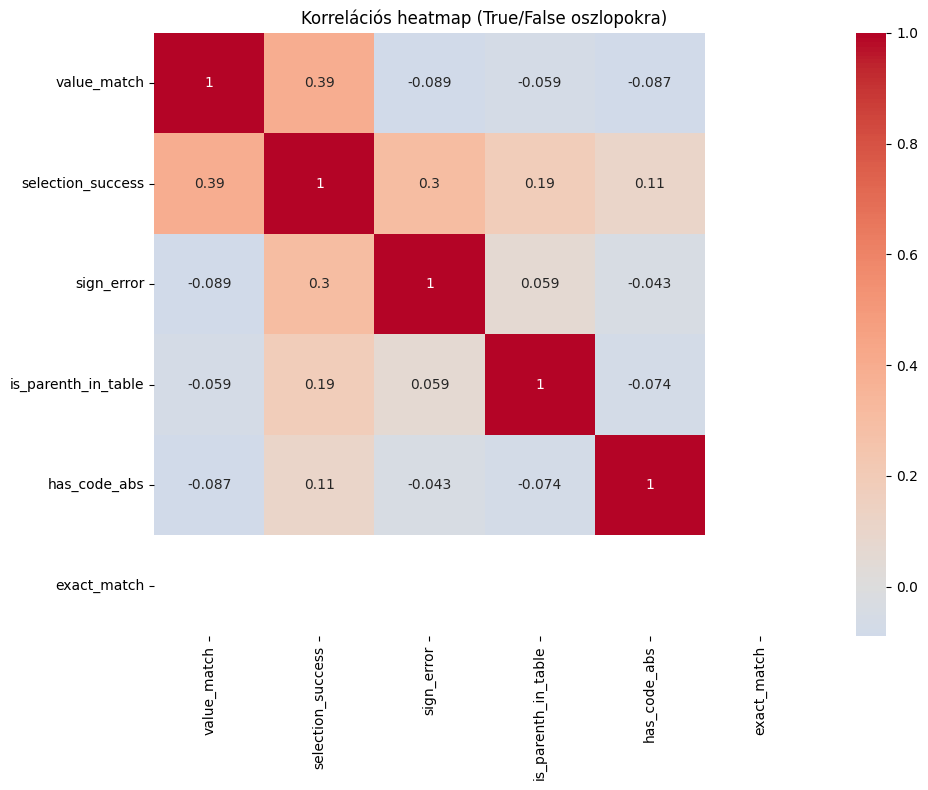

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = annotated_results.query('error_code != "none"')

# 1. Csak a True/False típusú oszlopokat szűrjük ki
bool_cols = df.select_dtypes(include=['bool'])

# 2. Korrelációs mátrix számítása
corr = bool_cols.corr()
em_corr = bool_cols.corr()['exact_match'].dropna().sort_values(ascending=False)

print(em_corr)

# 3. Heatmap megjelenítés
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)

plt.title("Korrelációs heatmap (True/False oszlopokra)")
plt.tight_layout()
plt.show()


In [42]:
bool_cols

,value_match,selection_success,sign_error,is_parenth_in_table,has_code_abs,exact_match
6,False,False,False,False,False,False
8,False,False,False,True,False,False
16,False,False,False,True,False,False
17,False,True,False,True,False,False
22,False,False,False,True,False,False
...,...,...,...,...,...,...
482,False,False,False,True,False,False
484,True,True,False,False,False,False
489,False,True,False,True,False,False
490,False,True,True,True,False,False
